# Building a Small Language Model from Scratch

## Learning Objectives

In this notebook, you will learn how to build a complete transformer-based language model from the ground up. We will implement every component step by step, understanding the mathematics and intuition behind each piece.

By the end of this notebook, you will have:
- Implemented multi-head self-attention from scratch
- Built positional encodings to give the model sequence awareness
- Created transformer blocks with feed-forward networks
- Assembled a complete language model
- Trained the model on text data
- Generated new text using your trained model

Let's begin our journey into the heart of modern language models!

## Part 1: Setup and Imports

First, we need to import the necessary libraries. We will use PyTorch as our deep learning framework because it provides excellent support for building custom neural network architectures and has become the standard in research.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Part 2: Tokenization and Vocabulary

Before we can process text, we need to convert it into numbers that our neural network can understand. This process is called tokenization. For simplicity, we will create a character-level tokenizer, meaning each character becomes a token.

In production systems, you would typically use subword tokenization methods like BPE or SentencePiece, but character-level tokenization is perfect for understanding the fundamentals.

In [2]:
class CharTokenizer:
    """A simple character-level tokenizer.
    
    This class converts text into sequences of integers, where each unique
    character gets its own integer ID. It also provides methods to convert
    back from integers to text.
    """
    
    def __init__(self, text):
        """Initialize the tokenizer by building a vocabulary from the text.
        
        Args:
            text (str): The text corpus to build vocabulary from
        """
        # Get all unique characters and sort them for consistency
        chars = sorted(list(set(text)))
        self.vocab_size = len(chars)
        
        # Create mappings: character to integer and integer to character
        self.char_to_idx = {ch: i for i, ch in enumerate(chars)}
        self.idx_to_char = {i: ch for i, ch in enumerate(chars)}
        
        print(f"Vocabulary size: {self.vocab_size}")
        print(f"Characters: {''.join(chars[:20])}..." if len(chars) > 20 else f"Characters: {''.join(chars)}")
    
    def encode(self, text):
        """Convert text to a list of integers.
        
        Args:
            text (str): Text to encode
            
        Returns:
            list: List of integer token IDs
        """
        return [self.char_to_idx[ch] for ch in text]
    
    def decode(self, indices):
        """Convert a list of integers back to text.
        
        Args:
            indices (list): List of integer token IDs
            
        Returns:
            str: Decoded text
        """
        return ''.join([self.idx_to_char[i] for i in indices])


# Load some sample text to work with
# For this example, we'll use a famous text that's small enough to train quickly
# but large enough to show interesting patterns

sample_text = """To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die—to sleep,
No more; and by a sleep to say we end
The heart-ache and the thousand natural shocks
That flesh is heir to: 'tis a consummation
Devoutly to be wish'd. To die, to sleep;
To sleep, perchance to dream—ay, there's the rub:
For in that sleep of death what dreams may come,
When we have shuffled off this mortal coil,
Must give us pause—there's the respect
That makes calamity of so long life."""

# Create tokenizer
tokenizer = CharTokenizer(sample_text)

# Test encoding and decoding
test_text = "To be"
encoded = tokenizer.encode(test_text)
decoded = tokenizer.decode(encoded)
print(f"\nOriginal: '{test_text}'")
print(f"Encoded: {encoded}")
print(f"Decoded: '{decoded}'")

Vocabulary size: 40
Characters: 
 ',-.:;ADFMNOTWabcd...

Original: 'To be'
Encoded: [14, 29, 1, 17, 20]
Decoded: 'To be'


## Part 3: Positional Encoding

Transformers process all tokens simultaneously, which is great for speed but means they have no inherent understanding of token order. We need to inject positional information into our embeddings.

We use sinusoidal positional encodings as described in the original "Attention Is All You Need" paper. These have a beautiful mathematical property: the encoding for position `pos+k` can be represented as a linear function of the encoding for position `pos`, which helps the model learn relative positions.

The formula is:
- PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
- PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

where `pos` is the position and `i` is the dimension.

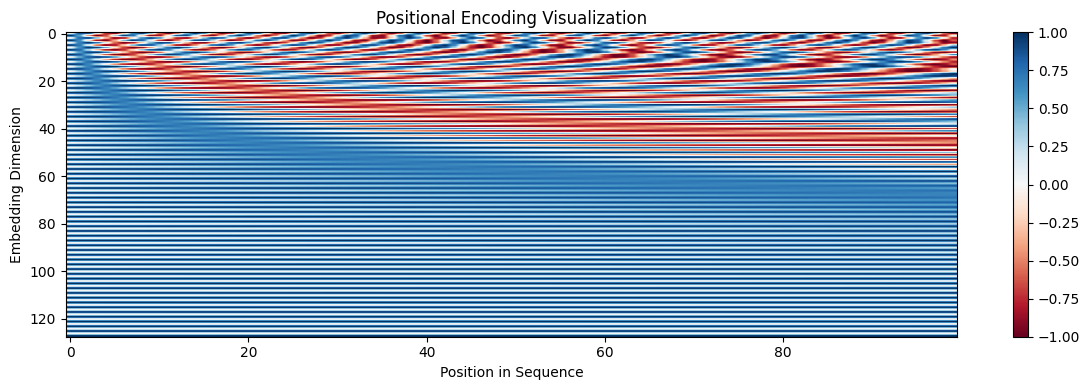

Notice how the positional encodings create unique patterns for each position.
The smooth sinusoidal waves help the model understand relative positions.


In [3]:
class PositionalEncoding(nn.Module):
    """Implements sinusoidal positional encoding.
    
    This adds information about the position of each token in the sequence,
    since transformers don't have any inherent notion of order.
    """
    
    def __init__(self, d_model, max_len=5000):
        """Initialize positional encoding.
        
        Args:
            d_model (int): The embedding dimension
            max_len (int): Maximum sequence length to pre-compute encodings for
        """
        super().__init__()
        
        # Create a matrix of shape (max_len, d_model) to hold positional encodings
        pe = torch.zeros(max_len, d_model)
        
        # Create position indices: [0, 1, 2, ..., max_len-1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # Create the division term for the sinusoidal functions
        # This creates different frequencies for different dimensions
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # Apply sine to even indices
        pe[:, 0::2] = torch.sin(position * div_term)
        
        # Apply cosine to odd indices
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Add batch dimension and register as buffer (not a parameter)
        pe = pe.unsqueeze(0)  # Shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        """Add positional encoding to input embeddings.
        
        Args:
            x (Tensor): Input embeddings of shape (batch_size, seq_len, d_model)
            
        Returns:
            Tensor: Embeddings with positional information added
        """
        # Add positional encoding to input
        # We slice [:, :x.size(1)] to match the sequence length
        x = x + self.pe[:, :x.size(1)]
        return x


# Visualize positional encodings
d_model = 128
pos_enc = PositionalEncoding(d_model)

# Create dummy input and get positional encodings
dummy_input = torch.zeros(1, 100, d_model)
encoded = pos_enc(dummy_input)

# Plot the positional encodings
plt.figure(figsize=(12, 4))
plt.imshow(encoded[0].T, cmap='RdBu', aspect='auto')
plt.colorbar()
plt.title('Positional Encoding Visualization')
plt.xlabel('Position in Sequence')
plt.ylabel('Embedding Dimension')
plt.tight_layout()
plt.show()

print("Notice how the positional encodings create unique patterns for each position.")
print("The smooth sinusoidal waves help the model understand relative positions.")

## Part 4: Multi-Head Self-Attention

This is the heart of the transformer architecture. Self-attention allows each token to look at all other tokens in the sequence and decide which ones are most relevant. The "multi-head" aspect means we do this multiple times in parallel, allowing the model to attend to different aspects of the input simultaneously.

The attention mechanism works in three steps:
1. **Create Queries, Keys, and Values**: Transform the input through learned linear projections
2. **Compute Attention Scores**: Determine how much each token should attend to every other token
3. **Apply Attention**: Use these scores to create a weighted combination of values

The mathematical formula is:
```
Attention(Q, K, V) = softmax(Q·K^T / √d_k)·V
```

In [4]:
class MultiHeadAttention(nn.Module):
    """Multi-head self-attention mechanism.
    
    This is the core component of transformers. It allows the model to attend
    to different parts of the sequence simultaneously from multiple perspectives.
    """
    
    def __init__(self, d_model, num_heads, dropout=0.1):
        """Initialize multi-head attention.
        
        Args:
            d_model (int): Embedding dimension
            num_heads (int): Number of attention heads
            dropout (float): Dropout probability
        """
        super().__init__()
        
        # Ensure d_model is divisible by num_heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Dimension per head
        
        # Linear projections for queries, keys, and values
        # We use a single linear layer for all heads for efficiency
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # Output projection
        self.W_o = nn.Linear(d_model, d_model)
        
        self.dropout = nn.Dropout(dropout)
    
    def split_heads(self, x):
        """Split the last dimension into (num_heads, d_k).
        
        Args:
            x (Tensor): Input of shape (batch_size, seq_len, d_model)
            
        Returns:
            Tensor: Reshaped to (batch_size, num_heads, seq_len, d_k)
        """
        batch_size, seq_len, d_model = x.size()
        # Reshape to (batch_size, seq_len, num_heads, d_k)
        x = x.view(batch_size, seq_len, self.num_heads, self.d_k)
        # Transpose to (batch_size, num_heads, seq_len, d_k)
        return x.transpose(1, 2)
    
    def combine_heads(self, x):
        """Combine multiple heads back into a single dimension.
        
        Args:
            x (Tensor): Input of shape (batch_size, num_heads, seq_len, d_k)
            
        Returns:
            Tensor: Combined to shape (batch_size, seq_len, d_model)
        """
        batch_size, num_heads, seq_len, d_k = x.size()
        # Transpose to (batch_size, seq_len, num_heads, d_k)
        x = x.transpose(1, 2)
        # Reshape to (batch_size, seq_len, d_model)
        return x.contiguous().view(batch_size, seq_len, self.d_model)
    
    def attention(self, Q, K, V, mask=None):
        """Compute scaled dot-product attention.
        
        Args:
            Q (Tensor): Queries of shape (batch_size, num_heads, seq_len, d_k)
            K (Tensor): Keys of shape (batch_size, num_heads, seq_len, d_k)
            V (Tensor): Values of shape (batch_size, num_heads, seq_len, d_k)
            mask (Tensor, optional): Attention mask
            
        Returns:
            Tensor: Attention output of shape (batch_size, num_heads, seq_len, d_k)
        """
        # Compute attention scores: Q·K^T / √d_k
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        # Apply mask if provided (for causal/autoregressive generation)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        
        # Apply softmax to get attention weights
        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        
        # Apply attention weights to values
        output = torch.matmul(attention_weights, V)
        
        return output
    
    def forward(self, x, mask=None):
        """Forward pass of multi-head attention.
        
        Args:
            x (Tensor): Input of shape (batch_size, seq_len, d_model)
            mask (Tensor, optional): Attention mask
            
        Returns:
            Tensor: Output of shape (batch_size, seq_len, d_model)
        """
        # Apply linear projections and split into multiple heads
        Q = self.split_heads(self.W_q(x))  # (batch_size, num_heads, seq_len, d_k)
        K = self.split_heads(self.W_k(x))  # (batch_size, num_heads, seq_len, d_k)
        V = self.split_heads(self.W_v(x))  # (batch_size, num_heads, seq_len, d_k)
        
        # Apply attention
        attention_output = self.attention(Q, K, V, mask)
        
        # Combine heads and apply output projection
        output = self.combine_heads(attention_output)
        output = self.W_o(output)
        
        return output


# Test multi-head attention
batch_size, seq_len, d_model = 2, 10, 128
num_heads = 8

mha = MultiHeadAttention(d_model, num_heads)
test_input = torch.randn(batch_size, seq_len, d_model)
output = mha(test_input)

print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print("\nMulti-head attention preserves the input shape while allowing each position")
print("to attend to all other positions in the sequence.")

Input shape: torch.Size([2, 10, 128])
Output shape: torch.Size([2, 10, 128])

Multi-head attention preserves the input shape while allowing each position
to attend to all other positions in the sequence.


## Part 5: Feed-Forward Network

After attention, each position passes through a position-wise feed-forward network. This is simply two linear transformations with a ReLU activation in between. Importantly, the same network is applied to each position independently.

The typical pattern is to expand the dimension by a factor of four in the hidden layer, then project back down. This expansion allows the network to learn complex transformations of the attended information.

Formula:
```
FFN(x) = ReLU(xW₁ + b₁)W₂ + b₂
```

In [5]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network.
    
    This applies two linear transformations with a ReLU activation in between.
    The same network is applied to each position separately and identically.
    """
    
    def __init__(self, d_model, d_ff, dropout=0.1):
        """Initialize feed-forward network.
        
        Args:
            d_model (int): Input and output dimension
            d_ff (int): Hidden layer dimension (typically 4 * d_model)
            dropout (float): Dropout probability
        """
        super().__init__()
        
        # First linear transformation (expansion)
        self.linear1 = nn.Linear(d_model, d_ff)
        
        # Second linear transformation (projection back)
        self.linear2 = nn.Linear(d_ff, d_model)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        """Forward pass.
        
        Args:
            x (Tensor): Input of shape (batch_size, seq_len, d_model)
            
        Returns:
            Tensor: Output of shape (batch_size, seq_len, d_model)
        """
        # Apply first linear layer and ReLU activation
        x = F.relu(self.linear1(x))
        x = self.dropout(x)
        
        # Apply second linear layer
        x = self.linear2(x)
        
        return x


# Test feed-forward network
d_ff = 512  # Typically 4 times d_model
ffn = FeedForward(d_model, d_ff)

test_input = torch.randn(batch_size, seq_len, d_model)
output = ffn(test_input)

print(f"Input shape: {test_input.shape}")
print(f"Hidden dimension: {d_ff}")
print(f"Output shape: {output.shape}")
print("\nThe feed-forward network expands the representation into a higher-dimensional")
print("space, applies non-linearity, then projects back to the original dimension.")

Input shape: torch.Size([2, 10, 128])
Hidden dimension: 512
Output shape: torch.Size([2, 10, 128])

The feed-forward network expands the representation into a higher-dimensional
space, applies non-linearity, then projects back to the original dimension.


## Part 6: Transformer Block

Now we combine all the pieces we have built into a complete transformer block. Each block consists of:
1. Multi-head self-attention
2. Add and normalize (residual connection + layer normalization)
3. Feed-forward network
4. Add and normalize (another residual connection + layer normalization)

The residual connections are crucial for training deep networks. They allow gradients to flow directly through the network, preventing the vanishing gradient problem. Layer normalization helps stabilize training by normalizing the inputs to each sub-layer.

In [6]:
class TransformerBlock(nn.Module):
    """A single transformer block.
    
    This combines multi-head attention and feed-forward layers with
    residual connections and layer normalization.
    """
    
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        """Initialize transformer block.
        
        Args:
            d_model (int): Embedding dimension
            num_heads (int): Number of attention heads
            d_ff (int): Feed-forward hidden dimension
            dropout (float): Dropout probability
        """
        super().__init__()
        
        # Multi-head self-attention
        self.attention = MultiHeadAttention(d_model, num_heads, dropout)
        
        # Feed-forward network
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        
        # Layer normalization layers
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # Dropout layers
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        """Forward pass through the transformer block.
        
        Args:
            x (Tensor): Input of shape (batch_size, seq_len, d_model)
            mask (Tensor, optional): Attention mask
            
        Returns:
            Tensor: Output of shape (batch_size, seq_len, d_model)
        """
        # Multi-head attention with residual connection and layer norm
        # Pattern: LayerNorm(x + Sublayer(x))
        attention_output = self.attention(x, mask)
        x = self.norm1(x + self.dropout1(attention_output))
        
        # Feed-forward with residual connection and layer norm
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout2(ff_output))
        
        return x


# Test transformer block
transformer_block = TransformerBlock(d_model, num_heads, d_ff)
test_input = torch.randn(batch_size, seq_len, d_model)
output = transformer_block(test_input)

print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print("\nThe transformer block processes the entire sequence, allowing each token")
print("to incorporate information from all other tokens through attention.")

Input shape: torch.Size([2, 10, 128])
Output shape: torch.Size([2, 10, 128])

The transformer block processes the entire sequence, allowing each token
to incorporate information from all other tokens through attention.


In [7]:
class LanguageModel(nn.Module):
    """A complete transformer-based language model.
    
    This is a decoder-only architecture that predicts the next token
    in a sequence given all previous tokens.
    """
    
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, 
                 max_seq_len, dropout=0.1):
        """Initialize the language model.
        
        Args:
            vocab_size (int): Size of the vocabulary
            d_model (int): Embedding dimension
            num_heads (int): Number of attention heads
            num_layers (int): Number of transformer blocks
            d_ff (int): Feed-forward hidden dimension
            max_seq_len (int): Maximum sequence length
            dropout (float): Dropout probability
        """
        super().__init__()
        
        self.d_model = d_model
        self.vocab_size = vocab_size
        
        # Token embeddings: convert token IDs to dense vectors
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        
        # Positional encoding: add position information
        self.pos_encoding = PositionalEncoding(d_model, max_seq_len)
        
        # Stack of transformer blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # Final layer normalization
        self.norm = nn.LayerNorm(d_model)
        
        # Output projection to vocabulary
        self.output_projection = nn.Linear(d_model, vocab_size)
        
        self.dropout = nn.Dropout(dropout)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        """Initialize model weights.
        
        We use Xavier/Glorot initialization for linear layers and
        normal initialization for embeddings.
        """
        for module in self.modules():
            if isinstance(module, nn.Linear):
                torch.nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    torch.nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                torch.nn.init.normal_(module.weight, mean=0, std=0.02)
    
    def generate_square_subsequent_mask(self, sz):
        """Generate a causal mask to prevent attending to future positions.
        
        This creates a triangular matrix where position i can only attend to
        positions 0 through i (not future positions).
        
        Args:
            sz (int): Sequence length
            
        Returns:
            Tensor: Mask of shape (sz, sz)
        """
        mask = torch.triu(torch.ones(sz, sz), diagonal=1).bool()
        return ~mask  # Invert so True means "attend to this position"
    
    def forward(self, x, mask=None):
        """Forward pass through the language model.
        
        Args:
            x (Tensor): Input token IDs of shape (batch_size, seq_len)
            mask (Tensor, optional): Attention mask
            
        Returns:
            Tensor: Logits of shape (batch_size, seq_len, vocab_size)
        """
        # Get sequence length
        seq_len = x.size(1)
        
        # Create causal mask if not provided
        if mask is None:
            mask = self.generate_square_subsequent_mask(seq_len).to(x.device)
        
        # Convert tokens to embeddings and scale by sqrt(d_model)
        # Scaling helps with training stability
        x = self.token_embedding(x) * math.sqrt(self.d_model)
        
        # Add positional encoding
        x = self.pos_encoding(x)
        x = self.dropout(x)
        
        # Pass through transformer blocks
        for transformer_block in self.transformer_blocks:
            x = transformer_block(x, mask)
        
        # Final layer norm
        x = self.norm(x)
        
        # Project to vocabulary size
        logits = self.output_projection(x)
        
        return logits
    
    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """Generate text autoregressively.
        
        Args:
            idx (Tensor): Starting token IDs of shape (batch_size, seq_len)
            max_new_tokens (int): Number of tokens to generate
            temperature (float): Sampling temperature (higher = more random)
            top_k (int, optional): If set, only sample from top k tokens
            
        Returns:
            Tensor: Generated token IDs
        """
        for _ in range(max_new_tokens):
            # Crop context if it exceeds maximum length
            idx_cond = idx if idx.size(1) <= 512 else idx[:, -512:]
            
            # Get predictions
            logits = self(idx_cond)
            
            # Focus on the last time step and apply temperature
            logits = logits[:, -1, :] / temperature
            
            # Optionally crop to top k logits
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            
            # Apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1)
            
            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)
            
            # Append sampled token to sequence
            idx = torch.cat((idx, idx_next), dim=1)
        
        return idx


# Initialize the model with small dimensions for quick training
model_config = {
    'vocab_size': tokenizer.vocab_size,
    'd_model': 128,
    'num_heads': 4,
    'num_layers': 4,
    'd_ff': 512,
    'max_seq_len': 512,
    'dropout': 0.1
}

model = LanguageModel(**model_config).to(device)

# Count parameters
num_params = sum(p.numel() for p in model.parameters())
print(f"Model initialized with {num_params:,} parameters")
print(f"\nModel configuration:")
for key, value in model_config.items():
    print(f"  {key}: {value}")

Model initialized with 803,624 parameters

Model configuration:
  vocab_size: 40
  d_model: 128
  num_heads: 4
  num_layers: 4
  d_ff: 512
  max_seq_len: 512
  dropout: 0.1


## Part 8: Dataset and DataLoader

Before we can train our model, we need to prepare our data. For language modeling, we need to create input-target pairs where the target is simply the input shifted by one position.

For example:
- Input: "To be or not to"
- Target: "be or not to be"

This teaches the model to predict the next token given all previous tokens.

In [8]:
class TextDataset(Dataset):
    """Dataset for language modeling.
    
    This creates sequences of tokens with their corresponding targets
    (the same sequence shifted by one position).
    """
    
    def __init__(self, text, tokenizer, seq_len):
        """Initialize the dataset.
        
        Args:
            text (str): Text corpus
            tokenizer: Tokenizer object
            seq_len (int): Length of each sequence
        """
        self.tokenizer = tokenizer
        self.seq_len = seq_len
        
        # Encode the entire text
        self.data = torch.tensor(tokenizer.encode(text), dtype=torch.long)
        
    def __len__(self):
        """Return the number of sequences in the dataset."""
        return len(self.data) - self.seq_len
    
    def __getitem__(self, idx):
        """Get a single training example.
        
        Returns:
            tuple: (input_sequence, target_sequence)
        """
        # Input is tokens from idx to idx+seq_len
        x = self.data[idx:idx + self.seq_len]
        
        # Target is the same sequence shifted by one
        y = self.data[idx + 1:idx + self.seq_len + 1]
        
        return x, y


# Create dataset and dataloader
seq_len = 64
batch_size = 16

dataset = TextDataset(sample_text, tokenizer, seq_len)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Dataset size: {len(dataset)} sequences")
print(f"Batch size: {batch_size}")
print(f"Sequence length: {seq_len}")
print(f"Number of batches: {len(dataloader)}")

# Show an example
x, y = dataset[0]
print(f"\nExample sequence:")
print(f"Input:  '{tokenizer.decode(x.tolist()[:30])}...'")
print(f"Target: '{tokenizer.decode(y.tolist()[:30])}...'")
print("\nNotice how the target is the input shifted by one position.")

Dataset size: 538 sequences
Batch size: 16
Sequence length: 64
Number of batches: 34

Example sequence:
Input:  'To be, or not to be, that is t...'
Target: 'o be, or not to be, that is th...'

Notice how the target is the input shifted by one position.


In [17]:
x, y

(tensor([28,  6,  0, 15, 23, 20, 34, 23, 20, 32,  1,  2, 34, 24, 33,  1, 28, 29,
         17, 26, 20, 32,  1, 24, 28,  1, 34, 23, 20,  1, 27, 24, 28, 19,  1, 34,
         29,  1, 33, 35, 21, 21, 20, 32,  0, 14, 23, 20,  1, 33, 26, 24, 28, 22,
         33,  1, 16, 28, 19,  1, 16, 32, 32, 29]),
 tensor([ 6,  0, 15, 23, 20, 34, 23, 20, 32,  1,  2, 34, 24, 33,  1, 28, 29, 17,
         26, 20, 32,  1, 24, 28,  1, 34, 23, 20,  1, 27, 24, 28, 19,  1, 34, 29,
          1, 33, 35, 21, 21, 20, 32,  0, 14, 23, 20,  1, 33, 26, 24, 28, 22, 33,
          1, 16, 28, 19,  1, 16, 32, 32, 29, 37]))

In [16]:
x, y = dataset[40]

print(f"Input:  '{tokenizer.decode(x.tolist()[:30])}...'")
print(f"Target: '{tokenizer.decode(y.tolist()[:30])}...'")

Input:  'n:
Whether 'tis nobler in the ...'
Target: ':
Whether 'tis nobler in the m...'


## Part 9: Training Loop

Now we implement the training loop. For each batch, we:
1. Pass input through the model to get predictions
2. Compute the cross-entropy loss between predictions and targets
3. Backpropagate the loss
4. Update model parameters

We also implement gradient clipping to prevent exploding gradients, which can destabilize training in deep networks.

In [9]:
def train_epoch(model, dataloader, optimizer, device):
    """Train the model for one epoch.
    
    Args:
        model: The language model
        dataloader: DataLoader for training data
        optimizer: Optimizer for updating parameters
        device: Device to train on (CPU or GPU)
        
    Returns:
        float: Average loss for the epoch
    """
    model.train()
    total_loss = 0
    
    for batch_idx, (x, y) in enumerate(dataloader):
        # Move data to device
        x, y = x.to(device), y.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        logits = model(x)
        
        # Compute loss
        # We need to reshape logits and targets for cross_entropy
        # logits: (batch_size, seq_len, vocab_size) -> (batch_size * seq_len, vocab_size)
        # targets: (batch_size, seq_len) -> (batch_size * seq_len)
        loss = F.cross_entropy(
            logits.view(-1, logits.size(-1)),
            y.view(-1)
        )
        
        # Backward pass
        loss.backward()
        
        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update parameters
        optimizer.step()
        
        total_loss += loss.item()
        
        # Print progress
        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch {batch_idx + 1}/{len(dataloader)}, Loss: {loss.item():.4f}")
    
    return total_loss / len(dataloader)


def train_model(model, dataloader, num_epochs, learning_rate, device):
    """Train the model for multiple epochs.
    
    Args:
        model: The language model
        dataloader: DataLoader for training data
        num_epochs (int): Number of epochs to train
        learning_rate (float): Learning rate for optimizer
        device: Device to train on (CPU or GPU)
        
    Returns:
        list: Loss history
    """
    # Use AdamW optimizer (Adam with weight decay)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    
    # Learning rate scheduler (cosine annealing)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs
    )
    
    loss_history = []
    
    print(f"Starting training for {num_epochs} epochs...\n")
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        
        # Train for one epoch
        avg_loss = train_epoch(model, dataloader, optimizer, device)
        loss_history.append(avg_loss)
        
        # Update learning rate
        scheduler.step()
        
        print(f"  Average Loss: {avg_loss:.4f}")
        print(f"  Learning Rate: {scheduler.get_last_lr()[0]:.6f}\n")
        
        # Generate sample text to see progress
        if (epoch + 1) % 5 == 0:
            model.eval()
            with torch.no_grad():
                # Start with "To be"
                prompt = "To be"
                context = torch.tensor(
                    [tokenizer.encode(prompt)], 
                    dtype=torch.long
                ).to(device)
                
                generated = model.generate(
                    context, 
                    max_new_tokens=50,
                    temperature=0.8,
                    top_k=40
                )
                
                generated_text = tokenizer.decode(generated[0].tolist())
                print(f"  Sample generation: '{generated_text}'\n")
            model.train()
    
    return loss_history


# Training hyperparameters
num_epochs = 50
learning_rate = 3e-4

print(f"Training configuration:")
print(f"  Epochs: {num_epochs}")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Sequence length: {seq_len}")
print(f"  Device: {device}\n")

Training configuration:
  Epochs: 50
  Learning rate: 0.0003
  Batch size: 16
  Sequence length: 64
  Device: cpu



## Part 10: Run Training

Now let's train our model! This will take a few minutes depending on your hardware. Watch how the loss decreases over time, and observe the generated samples to see the model learning to produce coherent text.

Note: With our small dataset and model, the results will be modest. In practice, language models are trained on billions of tokens with millions or billions of parameters.

Starting training for 50 epochs...

Epoch 1/50
  Batch 10/34, Loss: 3.1950
  Batch 20/34, Loss: 3.1307
  Batch 30/34, Loss: 3.0277
  Average Loss: 3.1899
  Learning Rate: 0.000300

Epoch 2/50
  Batch 10/34, Loss: 2.8518
  Batch 20/34, Loss: 2.6355
  Batch 30/34, Loss: 2.4551
  Average Loss: 2.7007
  Learning Rate: 0.000299

Epoch 3/50
  Batch 10/34, Loss: 2.3114
  Batch 20/34, Loss: 2.2767
  Batch 30/34, Loss: 2.1372
  Average Loss: 2.2668
  Learning Rate: 0.000297

Epoch 4/50
  Batch 10/34, Loss: 2.0573
  Batch 20/34, Loss: 2.0498
  Batch 30/34, Loss: 1.9074
  Average Loss: 2.0393
  Learning Rate: 0.000295

Epoch 5/50
  Batch 10/34, Loss: 1.8783
  Batch 20/34, Loss: 1.8424
  Batch 30/34, Loss: 1.7657
  Average Loss: 1.8350
  Learning Rate: 0.000293

  Sample generation: 'To bend therat sa. To dieereathe s dro f cowe athe to d'

Epoch 6/50
  Batch 10/34, Loss: 1.6632
  Batch 20/34, Loss: 1.5764
  Batch 30/34, Loss: 1.6699
  Average Loss: 1.6088
  Learning Rate: 0.000289

Epoch 7/50
  B

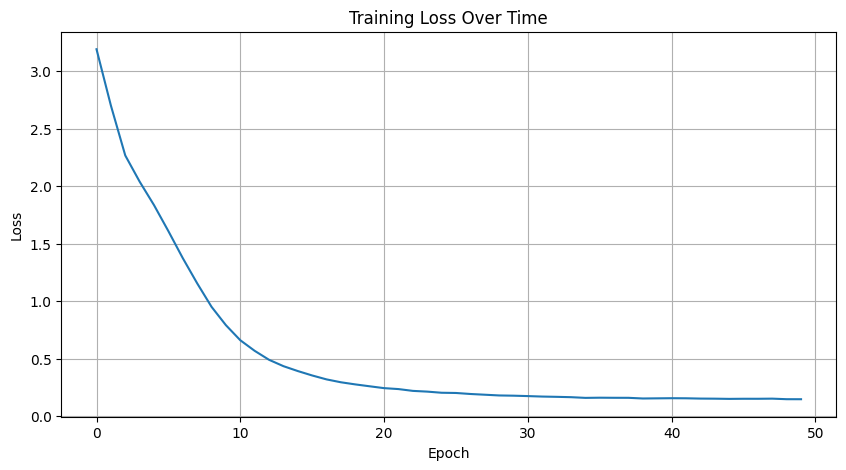

Training complete!
Final loss: 0.1483


In [10]:
# Train the model
loss_history = train_model(model, dataloader, num_epochs, learning_rate, device)

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

print("Training complete!")
print(f"Final loss: {loss_history[-1]:.4f}")

## Part 11: Text Generation

Now that our model is trained, let's use it to generate text! We can experiment with different sampling strategies:

- **Temperature**: Controls randomness. Lower values (0.5-0.7) make the model more deterministic and focused, while higher values (1.0-1.5) make it more creative and diverse.

- **Top-k sampling**: Only considers the k most likely next tokens. This prevents the model from sampling very unlikely tokens that might not make sense.

Try different prompts and parameters to see how the model responds!

In [18]:
def generate_text(model, tokenizer, prompt, max_length=100, temperature=1.0, top_k=None):
    """Generate text from a prompt.
    
    Args:
        model: Trained language model
        tokenizer: Tokenizer object
        prompt (str): Starting text
        max_length (int): Maximum length to generate
        temperature (float): Sampling temperature
        top_k (int, optional): Top-k sampling parameter
        
    Returns:
        str: Generated text
    """
    model.eval()
    
    with torch.no_grad():
        # Encode the prompt
        context = torch.tensor(
            [tokenizer.encode(prompt)], 
            dtype=torch.long
        ).to(device)
        
        # Generate tokens
        generated = model.generate(
            context,
            max_new_tokens=max_length,
            temperature=temperature,
            top_k=top_k
        )
        
        # Decode to text
        generated_text = tokenizer.decode(generated[0].tolist())
    
    return generated_text


# Try different generation parameters
prompts = [
    "To be",
    "The heart",
    "To die",
    "Whether"
]

print("=" * 80)
print("TEXT GENERATION EXAMPLES")
print("=" * 80)

for prompt in prompts:
    print(f"\nPrompt: '{prompt}'")
    print("-" * 80)
    
    # Generate with different temperatures
    for temp in [0.5, 1.0]:
        generated = generate_text(
            model, 
            tokenizer, 
            prompt, 
            max_length=80,
            temperature=temp,
            top_k=40
        )
        print(f"\nTemperature {temp}:")
        print(f"'{generated}'")
    print()

TEXT GENERATION EXAMPLES

Prompt: 'To be'
--------------------------------------------------------------------------------

Temperature 0.5:
'To be, or not to be, that is the question:
Whether 'tis nobler in the min mind the to'

Temperature 1.0:
'To be, pore; to sleep;
To sleep, perchance to dream—ay, there's the re rub:
Fo thathe'


Prompt: 'The heart'
--------------------------------------------------------------------------------

Temperature 0.5:
'The heart-ache and the thousand natural shocks
That flesh is heir to: 'tis a co: a a a a '

Temperature 1.0:
'The heart-ache and the thousd natural shocks
That flesh is heir to: 'tis 'tis coblis a a '


Prompt: 'To die'
--------------------------------------------------------------------------------

Temperature 0.5:
'To die, to sleep;
To sleep, perchance to dream—ay, there's the rub:
For in thathat sle'

Temperature 1.0:
'To die—to sleep;
To sleep, perchance to dream—ay, there's the rub:
For in thathat sle '


Prompt: 'Whether'
--------

## Part 12: Model Analysis and Understanding

Let's analyze what our model has learned by examining attention patterns and understanding how it processes text.

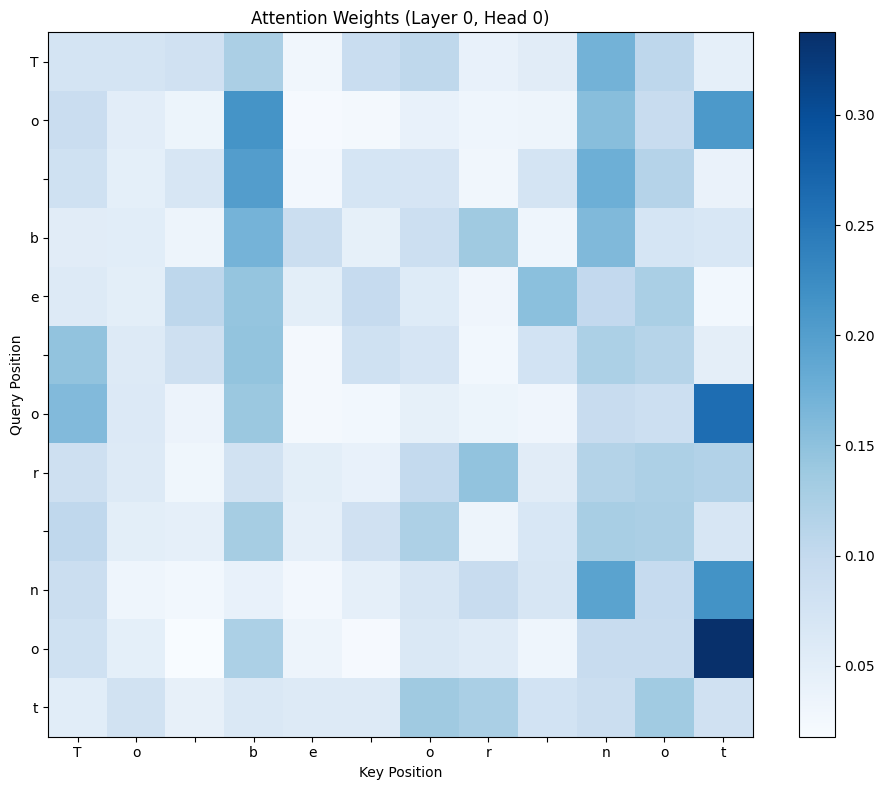

This heatmap shows how much each position (row) attends to other positions (columns).
Brighter colors indicate stronger attention.


In [19]:
def visualize_attention(model, tokenizer, text, layer_idx=0, head_idx=0):
    """Visualize attention weights for a given text.
    
    Args:
        model: Trained language model
        tokenizer: Tokenizer object
        text (str): Text to analyze
        layer_idx (int): Which transformer layer to visualize
        head_idx (int): Which attention head to visualize
    """
    model.eval()
    
    # Encode text
    tokens = tokenizer.encode(text)
    x = torch.tensor([tokens], dtype=torch.long).to(device)
    
    # Get the attention weights by modifying the forward pass temporarily
    # This is a simplified version - in practice you'd store attention weights
    # during the forward pass
    
    with torch.no_grad():
        # Get embeddings
        embeddings = model.token_embedding(x) * math.sqrt(model.d_model)
        embeddings = model.pos_encoding(embeddings)
        
        # Pass through specified layer's attention
        attention_module = model.transformer_blocks[layer_idx].attention
        
        # Get Q, K, V
        Q = attention_module.split_heads(attention_module.W_q(embeddings))
        K = attention_module.split_heads(attention_module.W_k(embeddings))
        
        # Compute attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(attention_module.d_k)
        attention_weights = F.softmax(scores, dim=-1)
        
        # Get attention for specific head
        head_attention = attention_weights[0, head_idx].cpu().numpy()
    
    # Visualize
    chars = [tokenizer.idx_to_char[idx] for idx in tokens]
    
    plt.figure(figsize=(10, 8))
    plt.imshow(head_attention, cmap='Blues')
    plt.colorbar()
    plt.xticks(range(len(chars)), chars)
    plt.yticks(range(len(chars)), chars)
    plt.xlabel('Key Position')
    plt.ylabel('Query Position')
    plt.title(f'Attention Weights (Layer {layer_idx}, Head {head_idx})')
    plt.tight_layout()
    plt.show()
    
    print(f"This heatmap shows how much each position (row) attends to other positions (columns).")
    print(f"Brighter colors indicate stronger attention.")


# Visualize attention for a short phrase
sample_text = "To be or not"
visualize_attention(model, tokenizer, sample_text, layer_idx=0, head_idx=0)

## Part 13: Exercises and Extensions

Now that you understand how to build a language model from scratch, here are some exercises to deepen your understanding:

### Exercise 1: Experiment with Architecture
Try modifying the model architecture:
- Change the number of layers (2, 4, 8)
- Adjust the number of attention heads
- Modify the embedding dimension
- Change the feed-forward dimension

How do these changes affect training time, final loss, and generation quality?

### Exercise 2: Different Sampling Strategies
Implement and compare:
- Greedy decoding (always pick most likely token)
- Top-p (nucleus) sampling
- Beam search

### Exercise 3: Larger Dataset
Train on a larger text corpus:
- Download a book from Project Gutenberg
- Train for more epochs
- Observe how model quality improves

### Exercise 4: Add More Features
Extend the model with:
- Dropout in different locations
- Weight decay
- Gradient accumulation for larger effective batch sizes
- Learning rate warmup

### Exercise 5: Evaluation Metrics
Implement proper evaluation:
- Split data into train/validation/test sets
- Compute perplexity on the validation set
- Track both training and validation loss

### Exercise 6: Save and Load Models
Add functionality to:
- Save model checkpoints during training
- Load pre-trained models
- Resume training from checkpoints

In [ ]:
# Exercise workspace
# Use this cell to experiment with the exercises above

# Example: Save the model
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': model_config,
    'loss_history': loss_history,
}, 'language_model.pt')

print("Model saved successfully!")

# Example: Load the model
# checkpoint = torch.load('language_model.pt')
# model.load_state_dict(checkpoint['model_state_dict'])
# print("Model loaded successfully!")

## Conclusion

Congratulations! You have successfully built a transformer-based language model from scratch. Let's review what you have learned:

### Key Concepts Covered:

1. **Tokenization**: Converting text to numerical representations
2. **Embeddings**: Mapping tokens to continuous vector spaces
3. **Positional Encoding**: Injecting sequence order information
4. **Self-Attention**: Allowing tokens to attend to each other
5. **Multi-Head Attention**: Multiple parallel attention mechanisms
6. **Feed-Forward Networks**: Non-linear transformations
7. **Residual Connections**: Enabling deep network training
8. **Layer Normalization**: Stabilizing training
9. **Causal Masking**: Autoregressive text generation
10. **Training Loop**: Optimizing model parameters
11. **Text Generation**: Sampling strategies for output

### Understanding the Architecture:

The transformer architecture you built is fundamentally the same as models like GPT, though scaled up dramatically. The key insights are:

- **Parallel Processing**: Unlike RNNs, transformers process entire sequences simultaneously
- **Attention Mechanism**: The core innovation allowing models to focus on relevant information
- **Scalability**: This architecture scales effectively to billions of parameters
- **Versatility**: The same architecture works for many NLP tasks

### Next Steps:

To continue your learning journey:

1. **Explore Pre-trained Models**: Use Hugging Face Transformers to work with state-of-the-art models
2. **Study Advanced Techniques**: Learn about techniques like RLHF, instruction tuning, and alignment
3. **Scale Up**: Train larger models on more data with distributed training
4. **Specialized Architectures**: Explore variants like encoder-decoder models, vision transformers, and more
5. **Research Papers**: Read the foundational papers to deepen your understanding

Remember: The models you use in production are built on these same principles, just scaled up with more data, parameters, and computational resources. Understanding these fundamentals gives you the foundation to work with and improve upon the most advanced language models.

Happy learning, and keep building!